# Machine Learning Project
# Employee Turnover

In [1]:
# Data Handling and Exploratory Data Analysis Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Model Preparation and Training Libraries

from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix , classification_report, roc_auc_score, RocCurveDisplay

In [2]:
# Getting the data
original_df = pd.read_csv("HR_comma_sep.csv")
original_df.head(2)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium


## Performing Data Quality Checks

In [3]:
# Verifying the Data
original_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Checking the values for each column
for c in original_df.columns:
    print(original_df[c].describe())
    print("\n")

count    14999.000000
mean         0.612834
std          0.248631
min          0.090000
25%          0.440000
50%          0.640000
75%          0.820000
max          1.000000
Name: satisfaction_level, dtype: float64


count    14999.000000
mean         0.716102
std          0.171169
min          0.360000
25%          0.560000
50%          0.720000
75%          0.870000
max          1.000000
Name: last_evaluation, dtype: float64


count    14999.000000
mean         3.803054
std          1.232592
min          2.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          7.000000
Name: number_project, dtype: float64


count    14999.000000
mean       201.050337
std         49.943099
min         96.000000
25%        156.000000
50%        200.000000
75%        245.000000
max        310.000000
Name: average_montly_hours, dtype: float64


count    14999.000000
mean         3.498233
std          1.460136
min          2.000000
25%          3.000000
50%          3.0000

In [5]:
# Checking the target column
original_df["left"].value_counts()

left
0    11428
1     3571
Name: count, dtype: int64

In [6]:
# Checking the categories in 'sales' column
original_df["sales"].value_counts()

sales
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64

## Heatmap of Correlation between all the numerical features.

<Axes: >

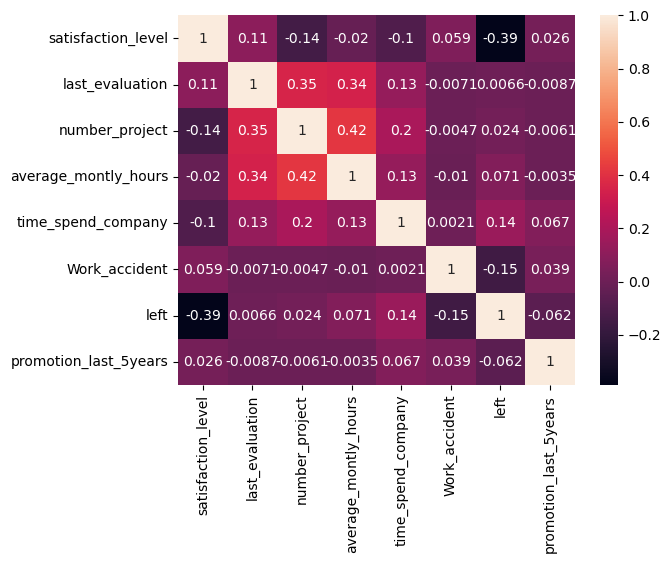

In [7]:
sns.heatmap(original_df.drop(["sales", "salary"], axis=1).corr(), annot=True)

## Exploratory Data Analysis

In [8]:
df = original_df.copy()

In [9]:
df["sales"] = df["sales"].replace(['sales', 'accounting', 'hr', 'technical', 'support', 'management','IT', 'product_mng', 'marketing', 'RandD'],
                                  ['Sales', 'Accounting', 'HR', 'Technical', 'Support', 'Management',       'IT', 'Product Management',
                                   'Marketing', 'R and D'])
df["salary"] = df["salary"].replace(['low', 'medium', 'high'], ['Low', 'Medium', 'High'])
df = df.rename(columns={"sales": "dept", "Work_accident": "work_accident"})
df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,dept,salary
11246,0.69,0.56,4,149,3,0,0,0,IT,Medium
5682,0.89,0.59,4,230,3,0,0,0,HR,Medium
14323,0.43,0.52,2,160,3,0,1,0,Technical,Low
2371,0.78,0.98,5,158,2,0,0,0,Marketing,Medium
285,0.40,0.56,2,148,3,0,1,0,Support,Low


In [10]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'work_accident', 'left',
       'promotion_last_5years', 'dept', 'salary'],
      dtype='object')

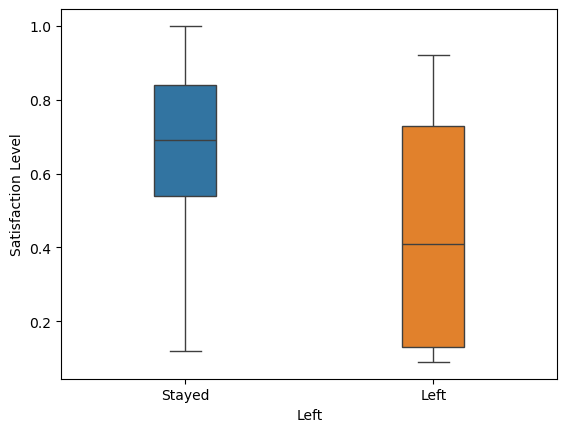

In [11]:
ax = sns.boxplot(data = df, x = "left", y = "satisfaction_level", hue = "left" , width= 0.25, legend=False)
ax.set(xlabel="Left", ylabel="Satisfaction Level")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Stayed", "Left"])
plt.show()

#### The graph shows that the people who leave usually have lower Satisfaction Level.

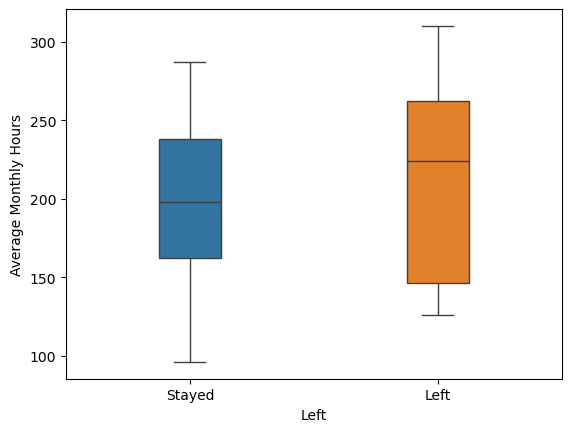

In [12]:
ax = sns.boxplot(data = df, x = "left", y = "average_montly_hours", hue = "left" , width= 0.25, legend=False)
ax.set(xlabel="Left", ylabel="Average Monthly Hours")
ax.set_xticks([0, 1])
ax.set_xticklabels(["Stayed", "Left"])
plt.show()

#### The graph shows that people who leave usually have higher monthly work hours.

### Distribution Plot of Satisfaction Level

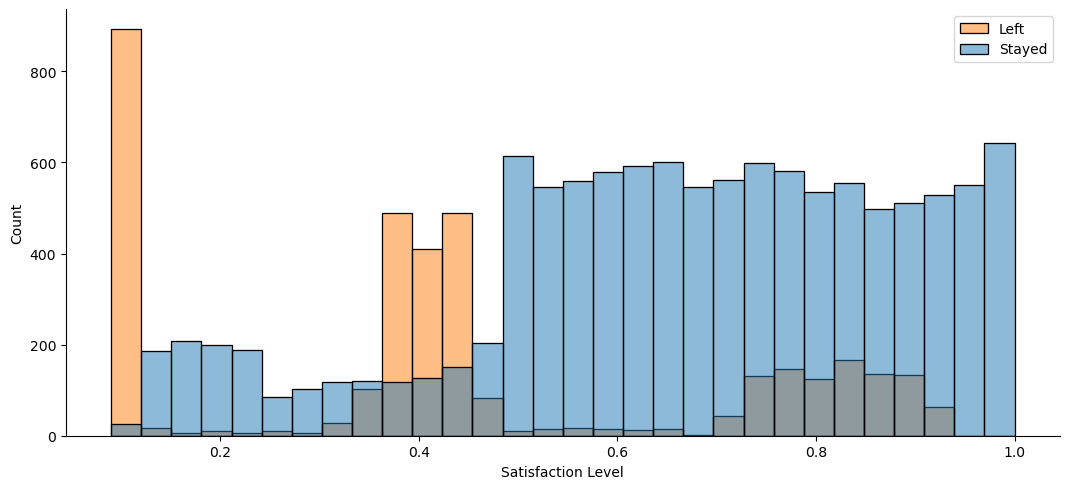

In [13]:
ax = sns.displot(df, x = "satisfaction_level", hue = "left", legend=False)
ax.figure.set_size_inches(12,5)
ax.set(xlabel = "Satisfaction Level")
# ax.add_legend({0: "Stayed", 1: "Left"})
# legend_handles, _ = plt.get_legend_handles_labels()
plt.legend(['Left','Stayed'])

### Distribution Plot of Last Evaluation Score

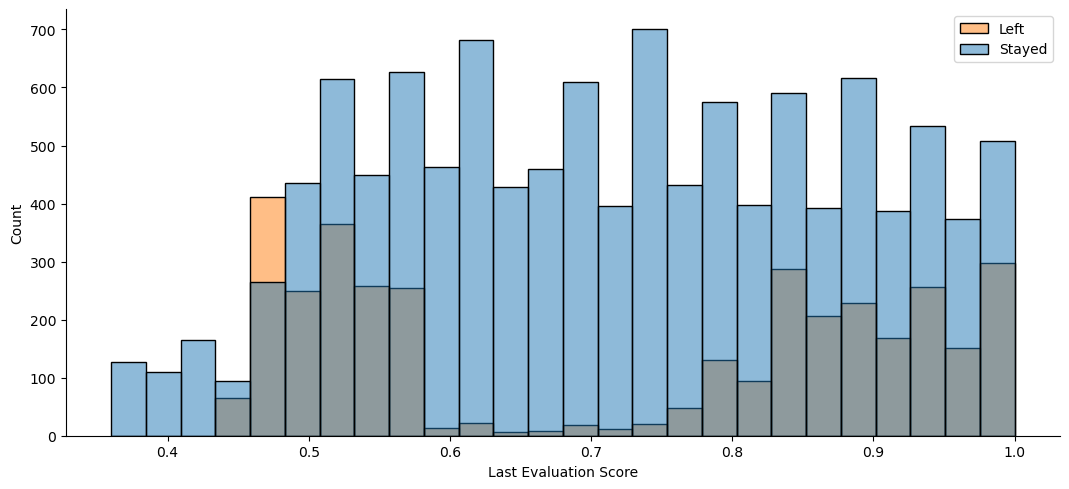

In [14]:
ax = sns.displot(df, x = "last_evaluation", hue = "left", legend=False)
ax.figure.set_size_inches(12,5)
ax.set(xlabel = "Last Evaluation Score")
# ax.add_legend({0: "Stayed", 1: "Left"})
# legend_handles, _ = plt.get_legend_handles_labels()
plt.legend(['Left','Stayed'])

### Distribution Plot of Last Evaluation Score

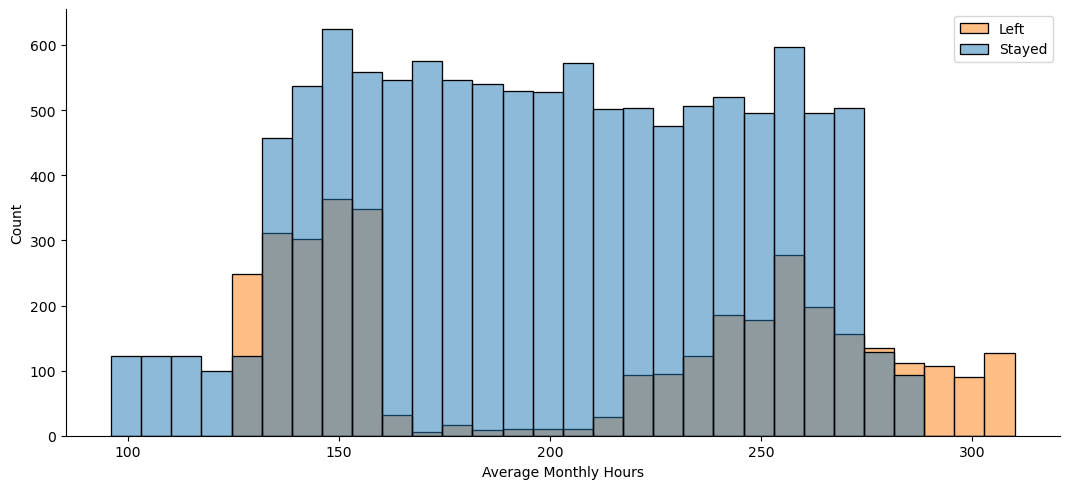

In [15]:
ax = sns.displot(df, x = "average_montly_hours", hue = "left", legend=False)
ax.figure.set_size_inches(12,5)
ax.set(xlabel = "Average Monthly Hours")
# ax.add_legend({0: "Stayed", 1: "Left"})
# legend_handles, _ = plt.get_legend_handles_labels()
plt.legend(['Left','Stayed'])

### Bar Plot of Number of Projects for Staying and  Leaving Employees

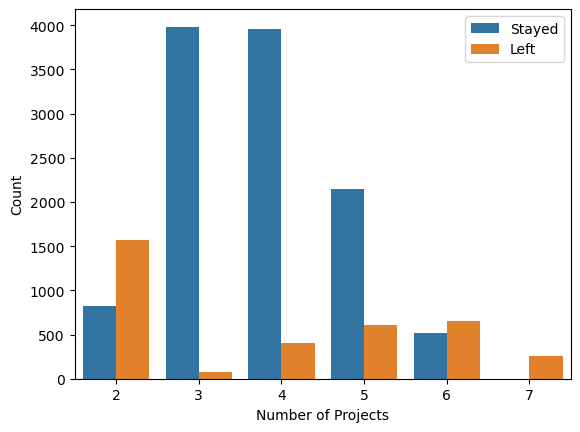

In [16]:
ax = sns.countplot(data = df, x = "number_project", hue = "left")
ax.set(xlabel="Number of Projects", ylabel="Count")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

## Various Other Relationship Plots

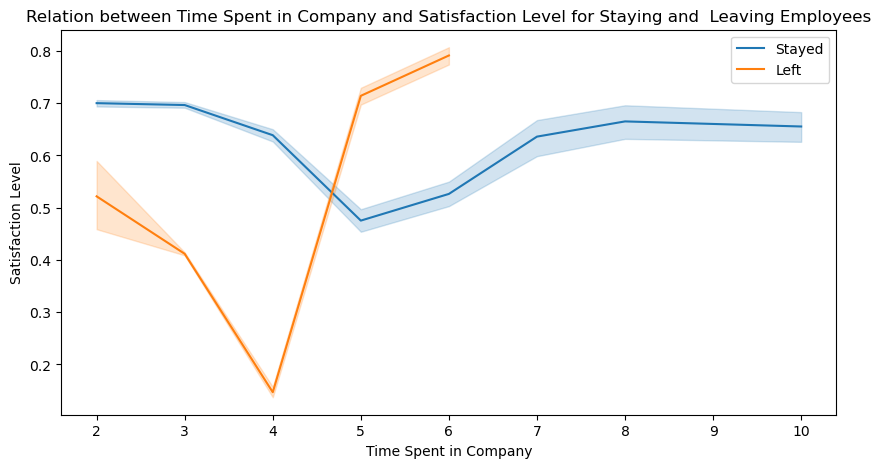

In [17]:
plt.subplots(figsize = (10, 5))
plt.title("Relation between Time Spent in Company and Satisfaction Level for Staying and  Leaving Employees")
ax = sns.lineplot(data = df, x = "time_spend_company", y = "satisfaction_level", hue = "left")
ax.set(xlabel="Time Spent in Company", ylabel="Satisfaction Level")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

#### 1. Employees that have a lower satisfaction level during the first four years usually tend to leave.
#### 2. Employees that have a high satisfaction level during the fifth and sixth years usually tend to leave.
#### 3. Employess that have stayed for 7 years or more do not leave.

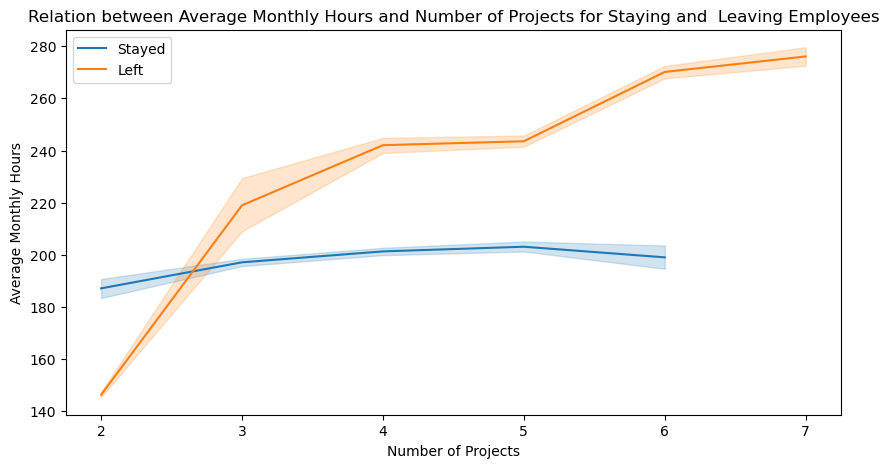

In [18]:
plt.subplots(figsize = (10, 5))
plt.title("Relation between Average Monthly Hours and Number of Projects for Staying and  Leaving Employees")
ax = sns.lineplot(data = df, x = "number_project", y = "average_montly_hours", hue = "left" )
ax.set(xlabel="Number of Projects", ylabel="Average Monthly Hours")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

In [19]:
print(df[(df["average_montly_hours"] > 200) & (df["number_project"] >= 3) & (df["left"] == 1)].shape[0] + df[(df["average_montly_hours"] < 160) & (df["number_project"] == 2) & (df["left"] == 1)].shape[0])
print(df[(df["left"] == 1)].shape[0])

3350
3571


#### Employees who left were mostly people who had three or more projects and worked for more than 200 hours or people with two projects who worked for less than 160 hours.

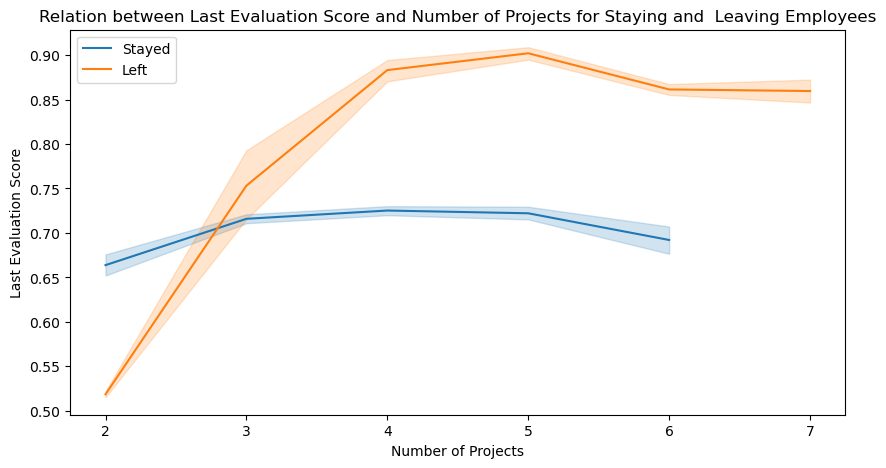

In [20]:
plt.subplots(figsize = (10, 5))
plt.title("Relation between Last Evaluation Score and Number of Projects for Staying and  Leaving Employees")
ax = sns.lineplot(data = df, x = "number_project", y = "last_evaluation", hue = "left" )
ax.set(xlabel="Number of Projects", ylabel="Last Evaluation Score")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

### All employees who have 7 projects have left.

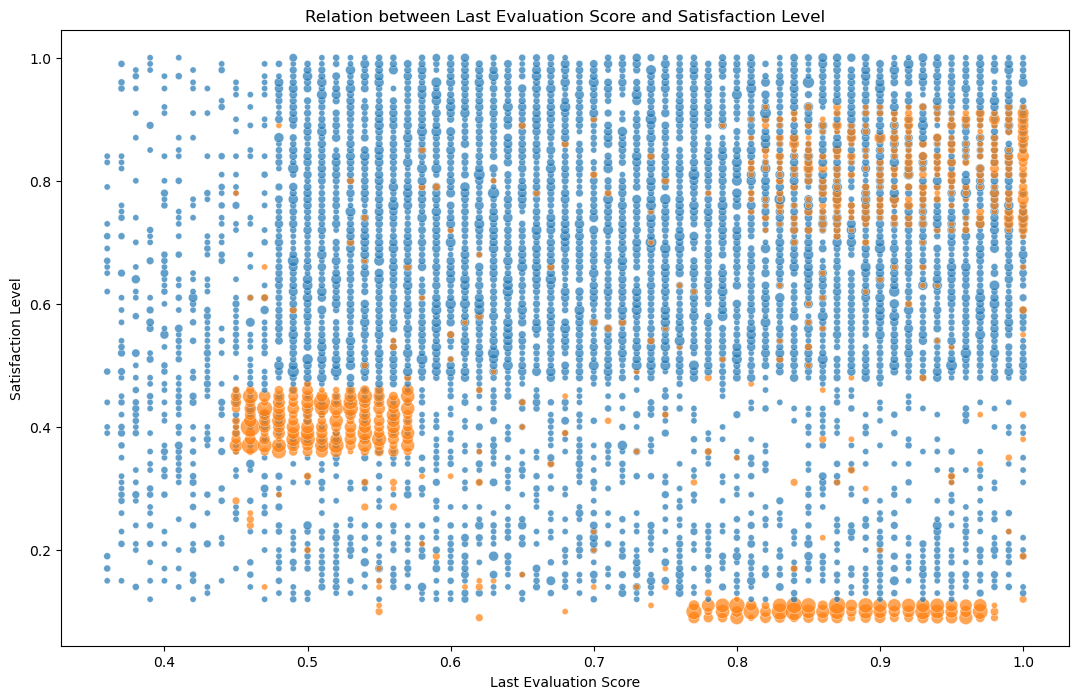

In [21]:
last_sat = df.groupby(["last_evaluation", "satisfaction_level", "left"]).size().reset_index(name = "Count")
plt.subplots(figsize=(13, 8))
plt.title("Relation between Last Evaluation Score and Satisfaction Level")
ax = sns.scatterplot(data=last_sat, x="last_evaluation", y="satisfaction_level", hue="left", size="Count", sizes=(20, 200), legend = False, alpha=0.7)
ax.set(xlabel="Last Evaluation Score", ylabel="Satisfaction Level")
plt.show()

#### The graph shows clear patterns regarding the employees who leave.

<Axes: xlabel='last_evaluation', ylabel='satisfaction_level'>

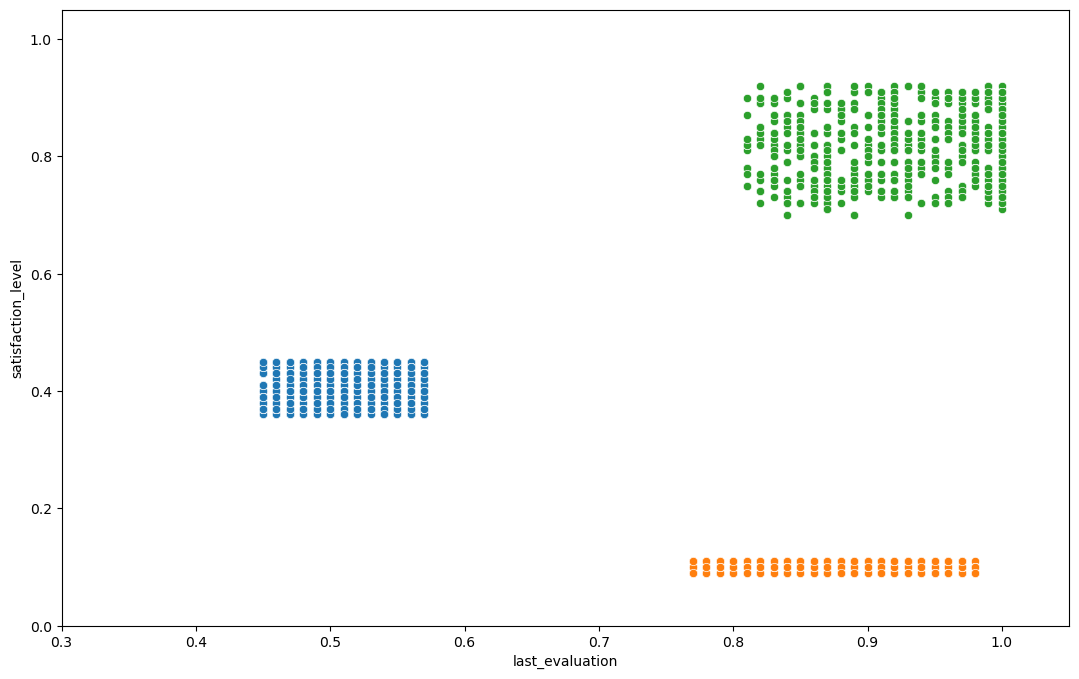

In [22]:
plt.subplots(figsize = (13, 8))
plt.xlim(0.3 , 1.05)
plt.ylim(0 , 1.05)
sns.scatterplot(data = df[(df["left"] == 1 ) & df["satisfaction_level"].between(0.35, 0.45) & df["last_evaluation"].between(0.45, 0.57)],
                x = "last_evaluation", y = "satisfaction_level")
sns.scatterplot(data = df[ df["satisfaction_level"].between(0, 0.11) & df["last_evaluation"].between(0.75, 1) & (df["left"] == 1 )],
                 x = "last_evaluation", y = "satisfaction_level")
sns.scatterplot(data = df[ df["satisfaction_level"].between(0.7, 0.92) & df["last_evaluation"].between(0.8, 1) & (df["left"] == 1 )],
                 x = "last_evaluation", y = "satisfaction_level")

The graph shows three groups of employees with higher chances of leaving, with -
- Satisfaction level between 0.35 and 0.45 and last evaluation score between 0.45 and 0.57
- Satisfaction level between 0 and 0.11 and last evaluation score between 0.75 and 1
- Satisfaction level between 0.7 and 0.92 and last evaluation score between 0.8 and 1

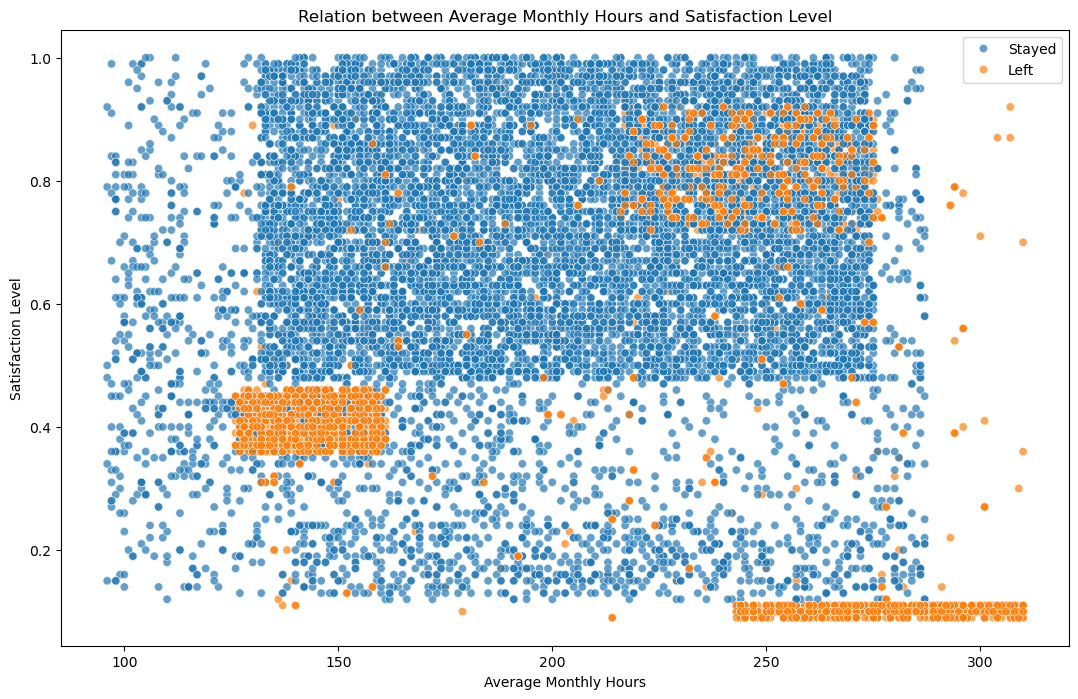

In [23]:
plt.subplots(figsize = (13, 8))
plt.title("Relation between Average Monthly Hours and Satisfaction Level")
ax = sns.scatterplot(data = df, x = "average_montly_hours", y = "satisfaction_level", hue = "left", alpha = 0.7)
ax.set(xlabel="Average Monthly Hours", ylabel="Satisfaction Level")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

#### This graph too shows clear patterns regarding employees who leave.

<Axes: xlabel='average_montly_hours', ylabel='satisfaction_level'>

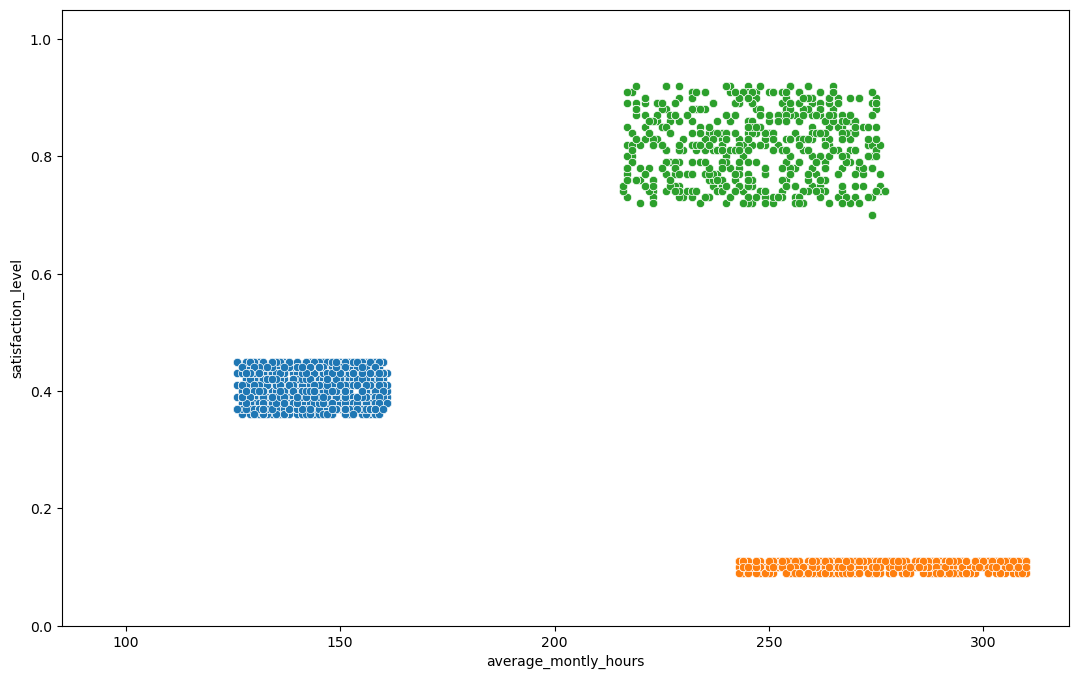

In [24]:
plt.subplots(figsize = (13, 8))
plt.xlim(85, 320)
plt.ylim(0 , 1.05)
sns.scatterplot(data = df[df["satisfaction_level"].between(0.35, 0.45) & df["average_montly_hours"].between(120, 170) & (df["left"] == 1 )],
                x = "average_montly_hours", y = "satisfaction_level" )
sns.scatterplot(data = df[df["satisfaction_level"].between(0, 0.11) & df["average_montly_hours"].between(240, 320) & (df["left"] == 1 )],
                x = "average_montly_hours", y = "satisfaction_level" )
sns.scatterplot(data = df[df["satisfaction_level"].between(0.7, 0.92) & df["average_montly_hours"].between(216, 280) & (df["left"] == 1 )],
                x = "average_montly_hours", y = "satisfaction_level" )

The graph shows three groups of employees with higher chances of leaving, with -
- Satisfaction level between 0.35 and 0.45 and average monthly hours between 120 and 170
- Satisfaction level between 0 and 0.11 and average monthly hours between 240 and 320
- Satisfaction level between 0.7 and 0.92 and average monthly hours between 216 and 280

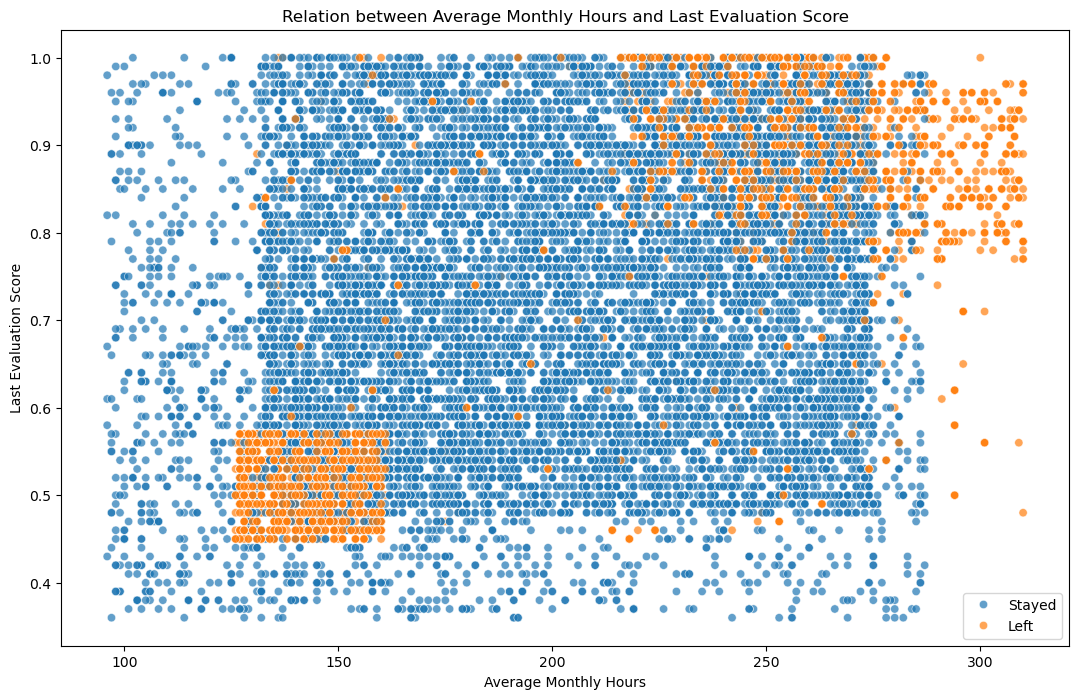

In [25]:
plt.subplots(figsize = (13, 8))
plt.title("Relation between Average Monthly Hours and Last Evaluation Score")
ax = sns.scatterplot(data = df, x = "average_montly_hours", y = "last_evaluation", hue = "left", alpha = 0.7)
ax.set(xlabel="Average Monthly Hours", ylabel="Last Evaluation Score")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

In [26]:
df[df["satisfaction_level"].between(0.35, 0.45) & df["average_montly_hours"].between(120, 170) &
df["last_evaluation"].between(0.45, 0.57)]["left"].value_counts(normalize = True)

left
1    0.971199
0    0.028801
Name: proportion, dtype: float64

### Over 97% of the people who have a *satisfaction level* between **0.35 and 0.45**, work between **120 to 170** *hours monthly* and have a *evaluation score* between **0.45 and 0.57** have left the organisation.

#### Dividing the above 97% by Salary

In [27]:
salary_compare = pd.concat([df[df["satisfaction_level"].between(0.35, 0.45) & df["average_montly_hours"].between(120, 170) &
                            df["last_evaluation"].between(0.45, 0.57) & (df["left"] == 1)]["salary"].value_counts(),
                            df[df["satisfaction_level"].between(0.35, 0.45) & df["average_montly_hours"].between(120, 170) &
                            df["last_evaluation"].between(0.45, 0.57)]["salary"].value_counts()], axis= 1)
salary_compare.columns = ["Left", "Total"]
salary_compare["Left Percantage"] = (salary_compare["Left"]/salary_compare["Total"])*100
salary_compare

,Left,Total,Left Percantage
salary,,,
Low,884,900,98.222222
Medium,521,543,95.948435
High,45,50,90.000000


In [28]:
df[df["satisfaction_level"].between(0.7, 0.92) & df["average_montly_hours"].between(216, 280) &
df["last_evaluation"].between(0.8, 1)]["left"].value_counts(normalize = True)

left
1    0.575352
0    0.424648
Name: proportion, dtype: float64

### Over 57% of the people who have a *satisfaction level* between **0.7 and 0.92**, work between **216 to 280** *hours monthly* and have a *evaluation score* between **0.8 and 1** have left the organisation.

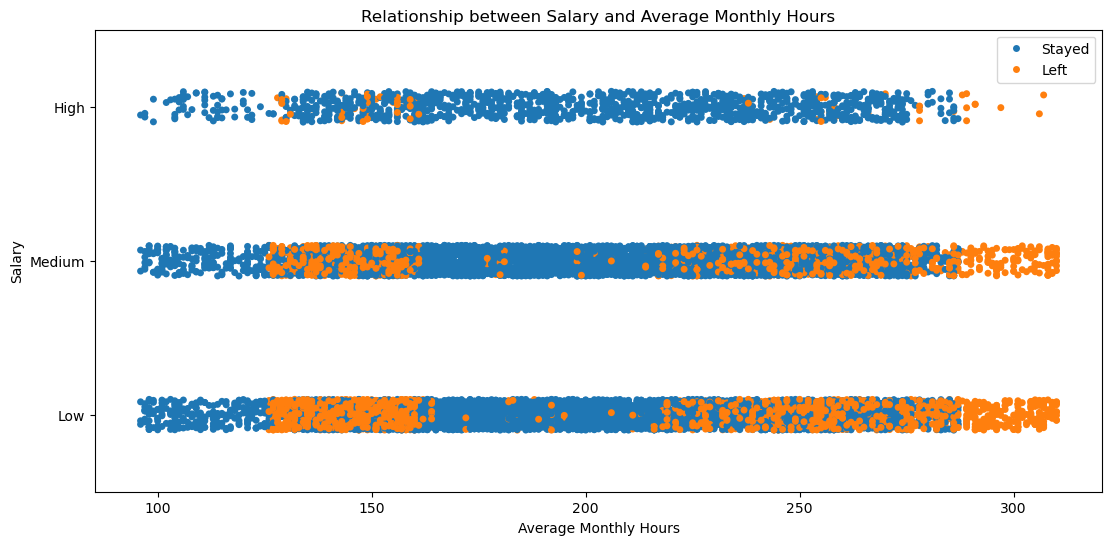

In [29]:
plt.subplots(figsize = (13, 6))
plt.title("Relationship between Salary and Average Monthly Hours")
ax = sns.stripplot(data=df, x = "average_montly_hours", y = "salary", hue="left", order=["High", "Medium", "Low"])
ax.set(xlabel="Average Monthly Hours", ylabel="Salary")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['Stayed','Left'])
plt.show()

#### Employees with low salary have a greater chance of leaving if their monthly work hours are between 120 and 170, or if it is greater than 250

In [30]:
df[df["left"] == 0]["average_montly_hours"].max()

287

### All employees who work more than 287 hours monthly on an average, have left.

In [31]:
df[df["left"] == 0]["satisfaction_level"].min()

0.12

### All employees who have a satisfaction level below 0.12 have left.

In [32]:
sal_order = ["High", "Medium", "Low", "All"]

In [33]:
df2 = (pd.crosstab(df[df["left"] == 1]["salary"], df[df["left"] == 1]["dept"], margins=True, margins_name="All")
 /pd.crosstab(df["salary"], df["dept"], margins=True, margins_name="All"))
df2 = df2.reindex(index=sal_order)
df2

dept,Accounting,HR,IT,Management,Marketing,Product Management,R and D,Sales,Support,Technical,All
salary,,,,,,,,,,,
High,0.067568,0.133333,0.048193,0.004444,0.112500,0.088235,0.078431,0.052045,0.056738,0.124378,0.066289
Medium,0.298507,0.325905,0.181308,0.137778,0.180851,0.227154,0.166667,0.170993,0.167728,0.256321,0.204313
Low,0.276536,0.274627,0.282430,0.327778,0.313433,0.232816,0.151099,0.332063,0.339442,0.275510,0.296884
All,0.265971,0.290934,0.222494,0.144444,0.236597,0.219512,0.153748,0.244928,0.248991,0.256250,0.238083


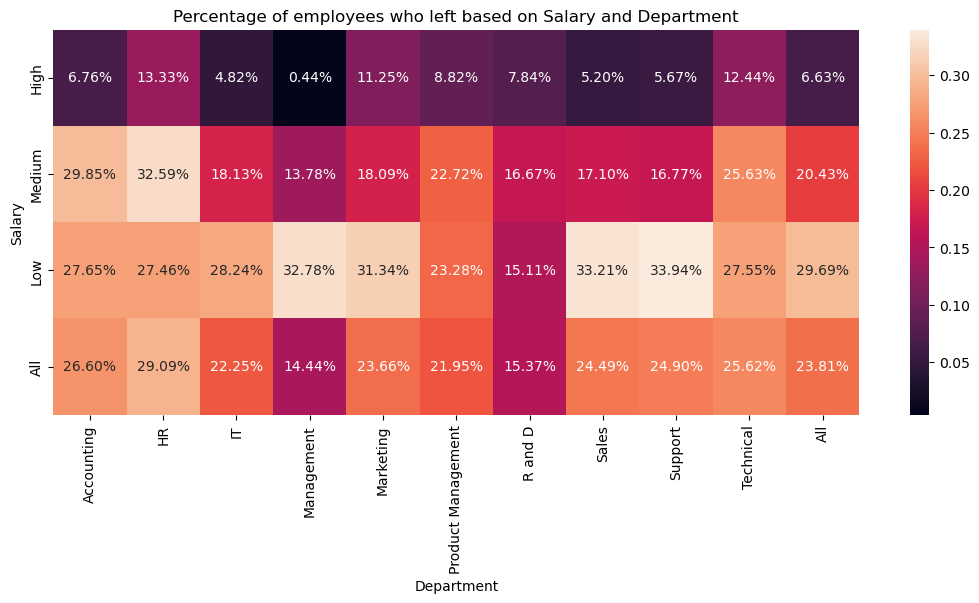

In [34]:
plt.subplots(figsize = (13, 5))
plt.title("Percentage of employees who left based on Salary and Department")
ax = sns.heatmap(df2, annot=True, fmt=".2%")
ax.set(xlabel="Department", ylabel="Salary")
plt.show()

#### 1. Support dept. employees with low salary have the highest chance of leaving.
#### 2. Sales dept. employees with low salary have the second highest chance of leaving.
#### 3. Management dept. employees with Medium salary have the third highest chance of leaving.
#### 4. Employees with low salary have the highest chance of leaving on an average.
#### 5. Employees of HR dept. have the highest chance of leaving on an average.

In [35]:
pd.crosstab(df["promotion_last_5years"], df["left"], margins=True, margins_name="All")

left,0,1,All
promotion_last_5years,,,
0,11128,3552,14680
1,300,19,319
All,11428,3571,14999


In [36]:
3552/14680

0.24196185286103541

### 24.2% of the people who did not recieve a promotion in the last five years left.
### Given that the average percentage of leaving employees is 23.81%, it would seem that getting a promotion in the last five years does not play a major role in deciding if an employee leaves.

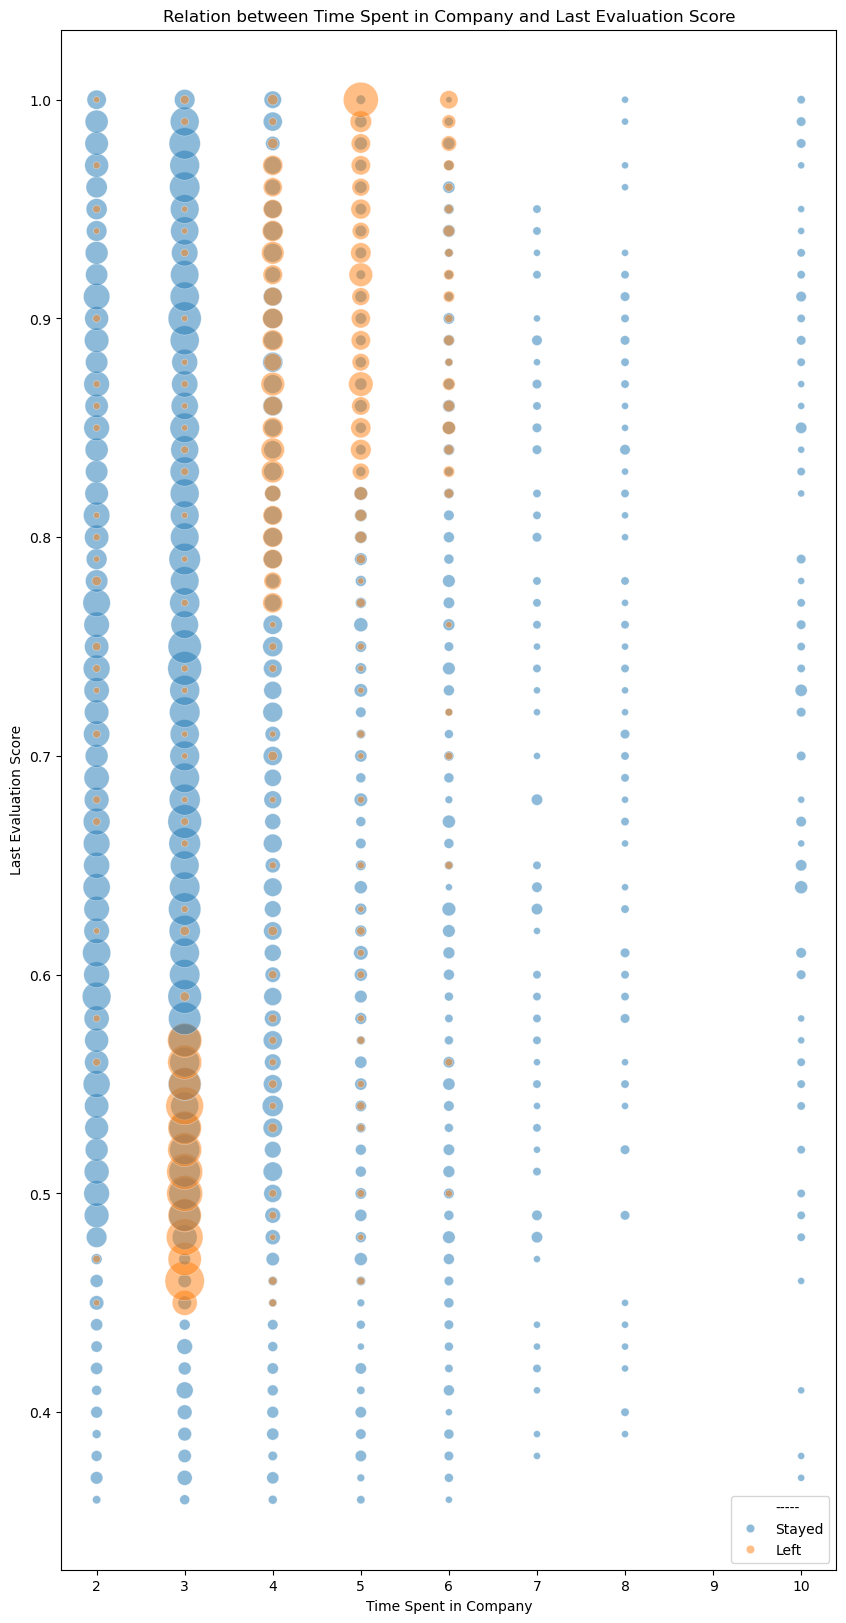

In [37]:
last_spent = df.groupby(["last_evaluation", "time_spend_company", "left"]).size().reset_index(name = "Count")

plt.subplots(figsize = (10, 20))
plt.title("Relation between Time Spent in Company and Last Evaluation Score")
ax = sns.scatterplot(data = last_spent, x = "time_spend_company", y = "last_evaluation", hue = "left", size = "Count", sizes = (20,800), alpha = 0.5)
ax.set(xlabel="Time Spent in Company", ylabel="Last Evaluation Score")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['-----', 'Stayed', 'Left'])
plt.show()

In [38]:
df3 = (pd.crosstab(df[df["left"] == 1]["number_project"], df[df["left"] == 1]["time_spend_company"], margins=True, margins_name="All")
 /pd.crosstab(df["number_project"], df["time_spend_company"], margins=True, margins_name="All"))
df3

time_spend_company,2,3,4,5,6,7,8,10,All
number_project,,,,,,,,,
2,0.031250,0.824164,0.102941,0.216867,0.000000,NaN,NaN,NaN,0.656198
3,0.008765,0.005051,0.056604,0.118519,0.043165,NaN,NaN,NaN,0.017756
4,0.014860,0.013348,0.043328,0.584270,0.386047,NaN,NaN,NaN,0.093700
5,0.016245,0.010393,0.113689,0.728041,0.508929,NaN,NaN,NaN,0.221659
6,0.121212,0.066176,0.835067,0.388889,0.068966,NaN,NaN,NaN,0.557922
7,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,1.000000
All,0.016338,0.246159,0.348064,0.565513,0.291086,NaN,NaN,NaN,0.238083


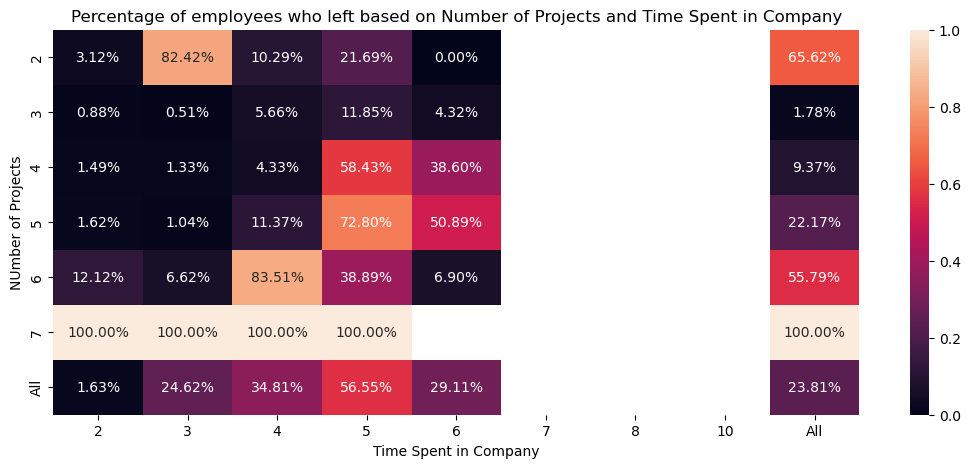

In [39]:
plt.subplots(figsize = (13, 5))
plt.title("Percentage of employees who left based on Number of Projects and Time Spent in Company")
ax = sns.heatmap(df3, annot=True, fmt=".2%")
ax.set(xlabel="Time Spent in Company", ylabel="NUmber of Projects")
plt.show()

### Other than the employees with 7 projects, the highest chance of leaving is for employees with 6 projects in their fourth year, followed by employees with 2 projects in their second year.

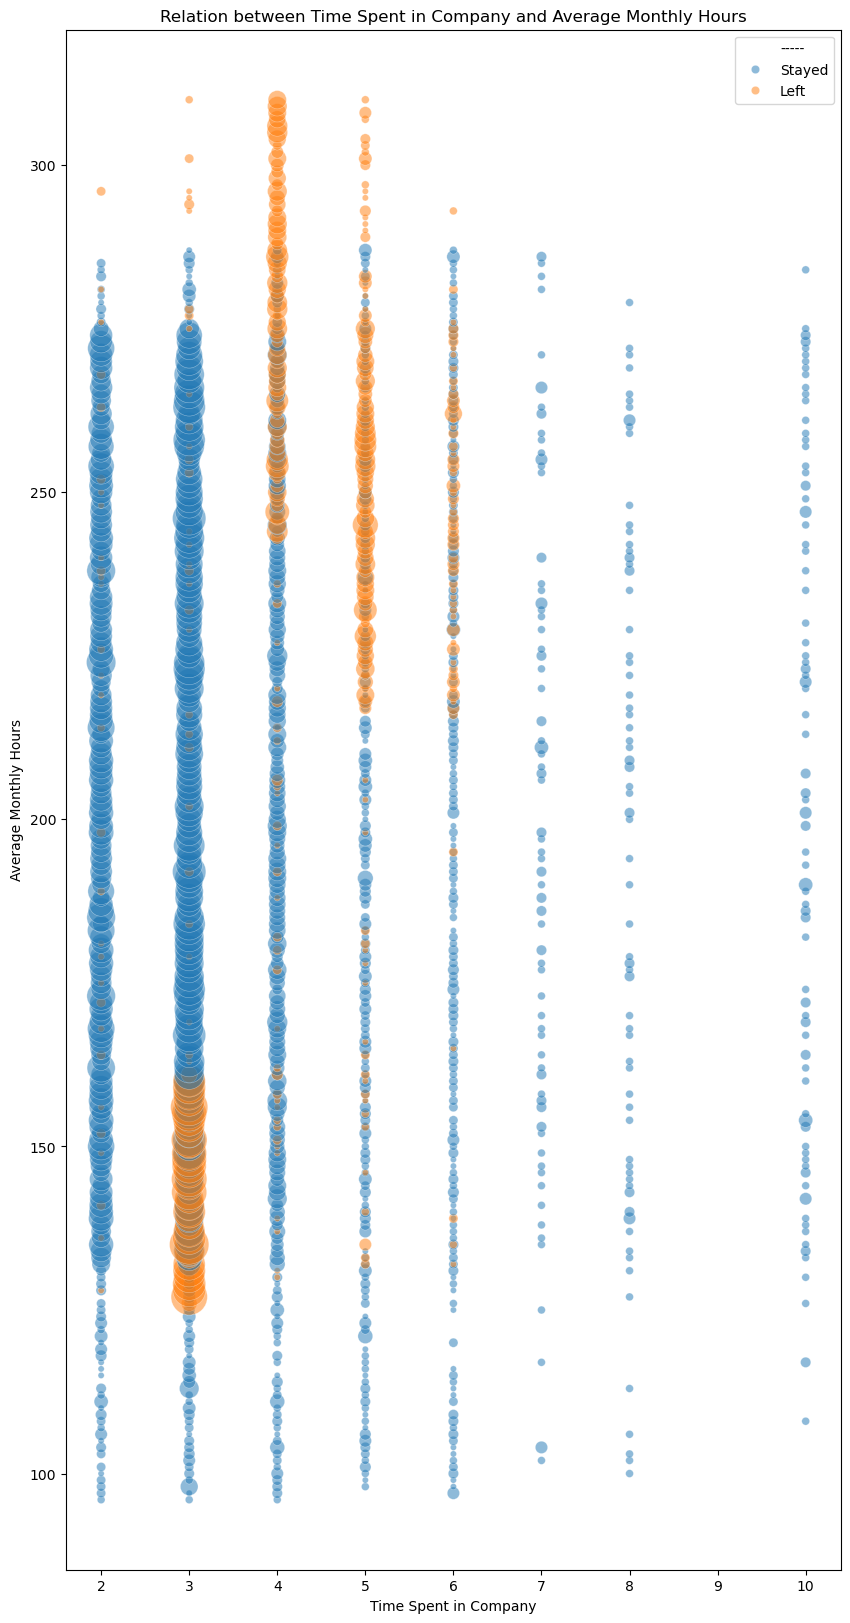

In [40]:
hours_spent = df.groupby(["average_montly_hours", "time_spend_company", "left"]).size().reset_index(name = "Count")

plt.subplots(figsize = (10, 20))
plt.title("Relation between Time Spent in Company and Average Monthly Hours")
ax = sns.scatterplot(data = hours_spent, x = "time_spend_company", y = "average_montly_hours", hue = "left", size = "Count", sizes = (20,800), alpha = 0.5)
ax.set(xlabel="Time Spent in Company", ylabel="Average Monthly Hours")
legend_handles, _= ax.get_legend_handles_labels()
ax.legend(legend_handles, ['-----', 'Stayed', 'Left'])
plt.show()

## Conclusion Based on the Data
### On an average there is a 23.81% chance of an employee leaving. Further:
#### 1. Employees with 7 projects have a **100%** chance of leaving.
#### 2. Employees with a Satisfaction Level below 0.12 have a **100%** chance of leaving.
#### 3. Employees who work for more than 287 hours a month have a **100%** chance of leaving.
#### 4. People who have a *satisfaction level* between **0.35 and 0.45**, work between **120 to 170** *hours monthly* and have a *evaluation score* between **0.45 and 0.57** have over **97%** chance of leaving.
#### 5. People who have a *satisfaction level* between **0.7 and 0.92**, work between **216 to 280** *hours monthly* and have a *evaluation score* between **0.8 and 1** have over **57%** chance of leaving.
#### 6. Employess that have stayed for 7 years or more do not leave.

## Data Preparation for Model Training

In [41]:
# Making a copy of the original data.
data_df = original_df.copy()

In [42]:
# Rename columns for greater accuracy and consistency.
data_df = data_df.rename(columns={"sales": "dept", "Work_accident": "work_accident"})
data_df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,dept,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [43]:
data_df["salary"].unique()

array(['low', 'medium', 'high'], dtype=object)

In [44]:
# Label Encoding for 'salary' column
data_df["salary"] = data_df["salary"].map({"low":1, "medium":2, "high":3})
data_df["salary"].value_counts()

salary
1    7316
2    6446
3    1237
Name: count, dtype: int64

In [45]:
# One-Hot Encoding for 'dept' column.
data_df = pd.get_dummies(data=data_df, columns=["dept"], drop_first=True)
data_df.sample(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
5479,0.54,0.69,4,168,2,0,0,0,1,False,False,False,True,False,False,False,False,False
12000,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,True,False,False
1841,0.84,1.00,5,242,5,0,1,0,1,False,False,False,False,False,False,True,False,False
305,0.45,0.47,2,135,3,0,1,0,2,True,False,False,False,False,False,False,False,False
12573,0.36,0.47,2,148,3,0,1,0,2,False,False,False,False,False,False,False,False,True


In [46]:
# scaler = MinMaxScaler()

# data_df = scaler.fit_transform(data_df.drop(["left"])
# data_df

### Clustering Employees who left based on Satisfaction Level and Last Evaluation Score using K-Means Clustering

In [47]:
km3 = KMeans(n_clusters=3)

In [48]:
kdf = data_df[data_df["left"] == 1][[ "satisfaction_level", "last_evaluation" ]]
kdf.head()

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


In [49]:
km3.fit(kdf)

KMeans(n_clusters=3)

In [50]:
km3.cluster_centers_.round(2)

array([[0.81, 0.91],
       [0.41, 0.52],
       [0.11, 0.87]])

In [51]:
centers = pd.DataFrame(km3.cluster_centers_, columns= kdf.columns[:2])
centers

,satisfaction_level,last_evaluation
0,0.808516,0.911709
1,0.410145,0.516982
2,0.111155,0.869301


In [52]:
km3.labels_

array([1, 0, 2, ..., 1, 2, 1])

In [53]:
kdf["cluster"] = km3.labels_
kdf.head()

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,1
1,0.80,0.86,0
2,0.11,0.88,2
3,0.72,0.87,0
4,0.37,0.52,1


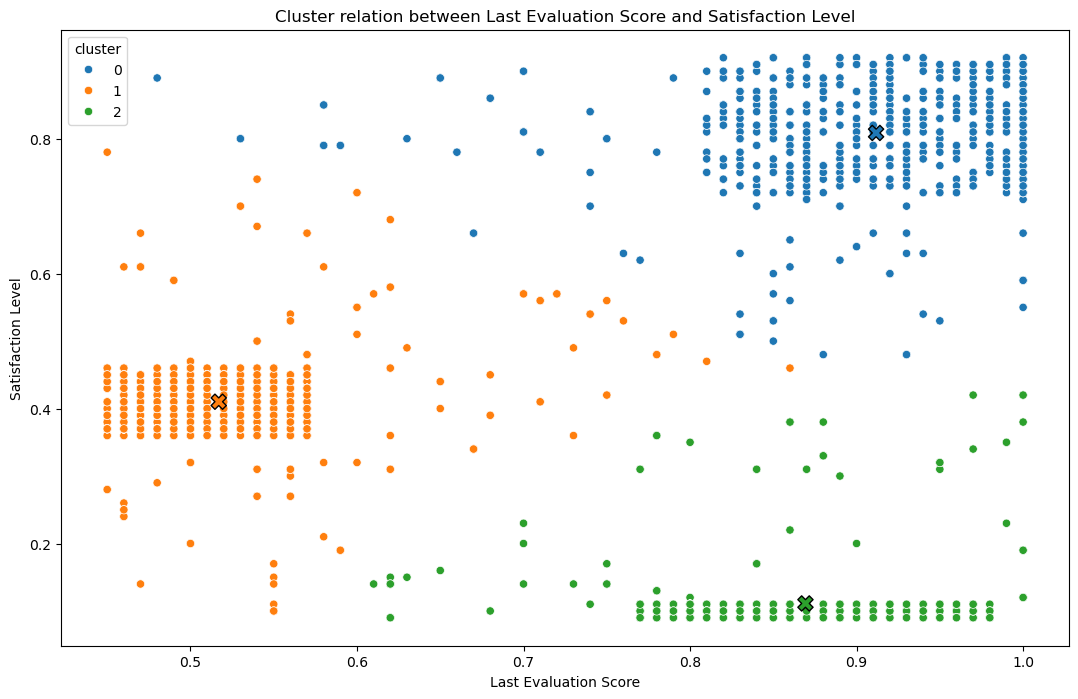

In [54]:
plt.subplots(figsize=(13, 8))
plt.title("Cluster relation between Last Evaluation Score and Satisfaction Level")
ax = sns.scatterplot(data=kdf, x="last_evaluation", y="satisfaction_level", hue="cluster", palette="tab10")
ax.set(xlabel="Last Evaluation Score", ylabel="Satisfaction Level")
sns.scatterplot(data=centers, x="last_evaluation", y="satisfaction_level", hue=centers.index, palette="tab10", legend=False,
                style=True, markers="X", s=120, edgecolor="black", linewidth=1)
plt.show()

#### The clusters centers are shown with an 'X' symbol in the respective colors.

#### The clusters match the conclusions obtained in the EDA Phase.

## Data Preparation for Predictive Models

In [55]:
sdf = data_df.copy()
sdf.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,left,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,1,0,1,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,1,0,2,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,1,0,2,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,1,0,1,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,1,0,1,False,False,False,False,False,False,True,False,False


In [56]:
# Defining the Logistic Regression Model
reg = LogisticRegression(max_iter=1000)

# Defining the Random Forest Classifier Model
rfc = RandomForestClassifier(n_estimators = 100, n_jobs = -1)

# Defining the Gradient Boosting Classifier Model
gbc = GradientBoostingClassifier(max_depth=5)

# Defining the Cross Validation Model
validator = StratifiedKFold(n_splits=5, random_state=123, shuffle=True)

# Defining the Scaling Model
scaler = MinMaxScaler()

# Defining the Oversmapling Model
smote = SMOTE(random_state=123)

In [57]:
#  Creating and verifying X.
x = sdf.drop(["left"], axis=1)
x.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
0,0.38,0.53,2,157,3,0,0,1,False,False,False,False,False,False,True,False,False
1,0.80,0.86,5,262,6,0,0,2,False,False,False,False,False,False,True,False,False
2,0.11,0.88,7,272,4,0,0,2,False,False,False,False,False,False,True,False,False
3,0.72,0.87,5,223,5,0,0,1,False,False,False,False,False,False,True,False,False
4,0.37,0.52,2,159,3,0,0,1,False,False,False,False,False,False,True,False,False


In [58]:
#  Creating and verifying Y.
y = sdf["left"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: left, dtype: int64

#### Ideally **Recall** should be targeted first as it would be best to reduce the false negatives first. Employees who are predicted to stay, but leave the organisation, will cause more impact.

### Logistic Regression with 5-Fold CV

Confusion Matrix
[[1746  539]
 [ 149  566]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.76      0.84      2285
           1       0.51      0.79      0.62       715

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.82      0.77      0.78      3000


 ROC AUC Score : 0.778



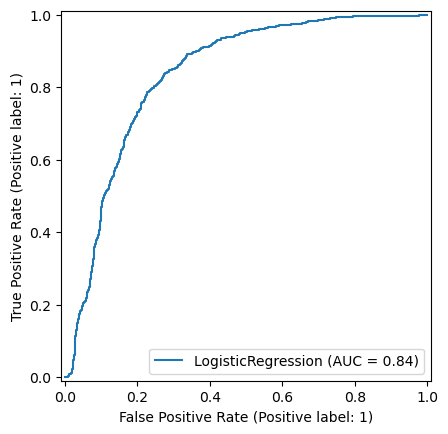



Confusion Matrix
[[1731  555]
 [ 155  559]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      2286
           1       0.50      0.78      0.61       714

    accuracy                           0.76      3000
   macro avg       0.71      0.77      0.72      3000
weighted avg       0.82      0.76      0.78      3000


 ROC AUC Score : 0.77



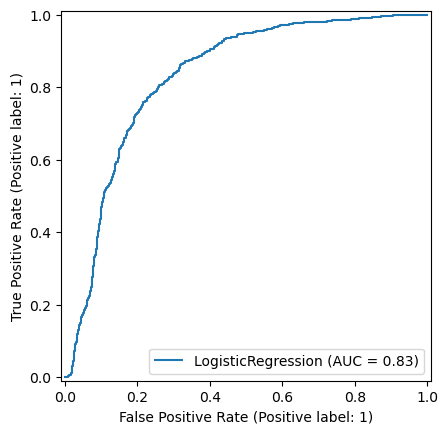



Confusion Matrix
[[1639  647]
 [ 159  555]]

Classification Report
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      2286
           1       0.46      0.78      0.58       714

    accuracy                           0.73      3000
   macro avg       0.69      0.75      0.69      3000
weighted avg       0.80      0.73      0.75      3000


 ROC AUC Score : 0.747



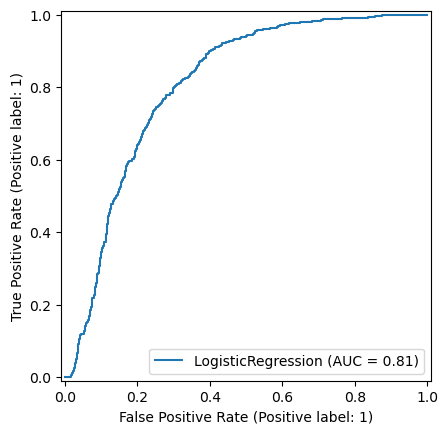



Confusion Matrix
[[1677  609]
 [ 122  592]]

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.73      0.82      2286
           1       0.49      0.83      0.62       714

    accuracy                           0.76      3000
   macro avg       0.71      0.78      0.72      3000
weighted avg       0.83      0.76      0.77      3000


 ROC AUC Score : 0.781



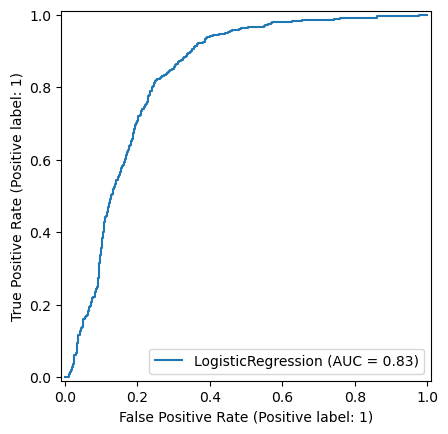



Confusion Matrix
[[1714  571]
 [ 139  575]]

Classification Report
              precision    recall  f1-score   support

           0       0.92      0.75      0.83      2285
           1       0.50      0.81      0.62       714

    accuracy                           0.76      2999
   macro avg       0.71      0.78      0.72      2999
weighted avg       0.82      0.76      0.78      2999


 ROC AUC Score : 0.778



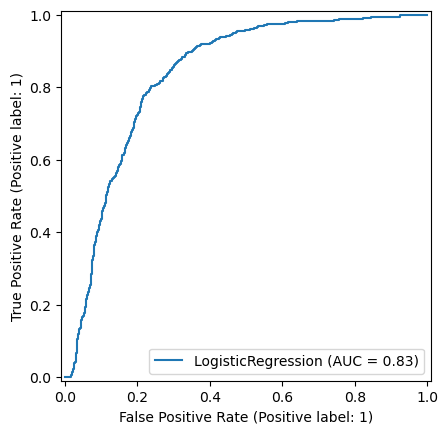

In [59]:
for train_data, test_data in validator.split(x, y):
    # Dividing the data into the different categories
    x_train = x.loc[train_data]
    y_train = y.loc[train_data]
    x_test = x.loc[test_data]
    y_test = y.loc[test_data]

    # Scaling the data
    x_train_sc = scaler.fit_transform(x_train)
    x_test_sc = scaler.transform(x_test)
    
    # Apply oversampling to the data.
    x_train_smote, y_train_smote = smote.fit_resample(x_train_sc, y_train)
    
    # Using the data to fit the Learning Model 
    reg.fit(x_train_smote, y_train_smote)
    pred = reg.predict(x_test_sc)

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))
    print("\nClassification Report")
    print(classification_report(y_test, pred))
    print("\n ROC AUC Score :", roc_auc_score(y_test, pred).round(3))
    print("")

    log_disp = RocCurveDisplay.from_estimator(reg, x_test_sc, y_test)
    plt.show()

    print("\n")

### Random Forest with 5-Fold CV

Confusion Matrix
[[2282    3]
 [  15  700]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2285
           1       1.00      0.98      0.99       715

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


 ROC AUC Score : 0.989



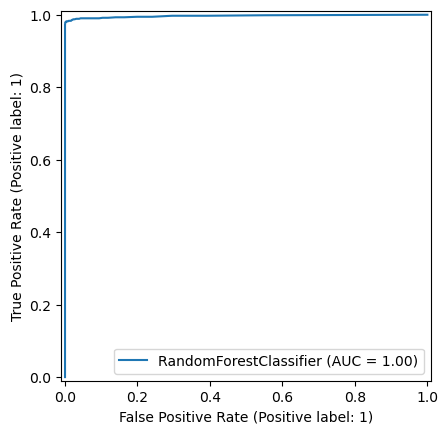



Confusion Matrix
[[2282    4]
 [  18  696]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2286
           1       0.99      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000


 ROC AUC Score : 0.987



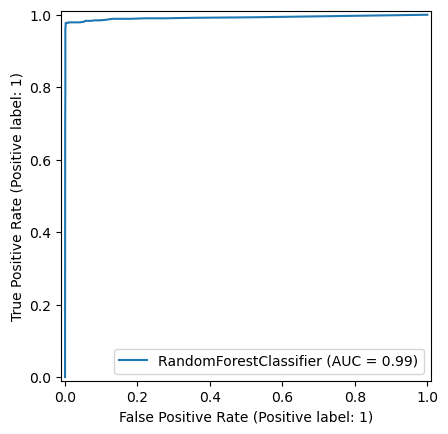



Confusion Matrix
[[2277    9]
 [  19  695]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       0.99      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000


 ROC AUC Score : 0.985



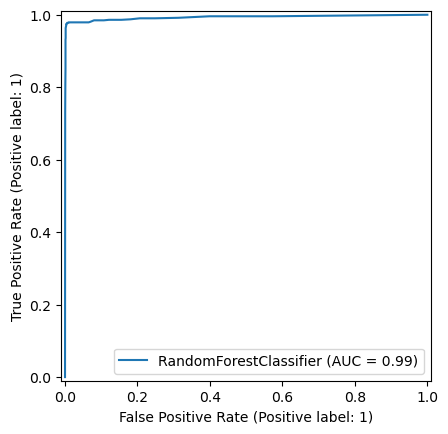



Confusion Matrix
[[2274   12]
 [  27  687]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2286
           1       0.98      0.96      0.97       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.98      3000
weighted avg       0.99      0.99      0.99      3000


 ROC AUC Score : 0.978



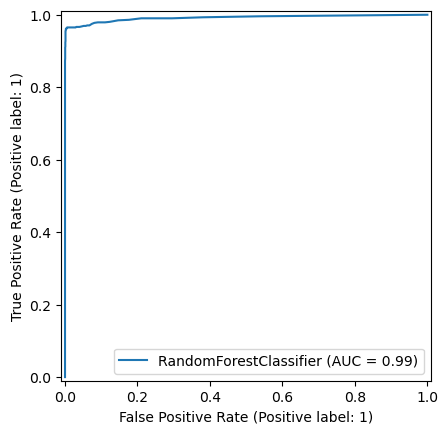



Confusion Matrix
[[2278    7]
 [  19  695]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2285
           1       0.99      0.97      0.98       714

    accuracy                           0.99      2999
   macro avg       0.99      0.99      0.99      2999
weighted avg       0.99      0.99      0.99      2999


 ROC AUC Score : 0.985



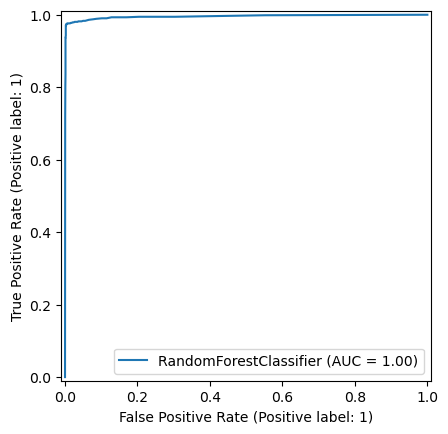

In [60]:
for train_data, test_data in validator.split(x, y):
    # Dividing the data into the different categories
    x_train = x.loc[train_data]
    y_train = y.loc[train_data]
    x_test = x.loc[test_data]
    y_test = y.loc[test_data]

    # Scaling the data
    x_train_sc = scaler.fit_transform(x_train)
    x_test_sc = scaler.transform(x_test)
    
    # Apply oversampling to the data.
    x_train_smote, y_train_smote = smote.fit_resample(x_train_sc, y_train)
    
    # Using the data to fit the Learning Model 
    rfc.fit(x_train_smote, y_train_smote)
    pred = rfc.predict(x_test_sc)

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))
    print("\nClassification Report")
    print(classification_report(y_test, pred))
    print("\n ROC AUC Score :", roc_auc_score(y_test, pred).round(3))
    print("")

    log_disp = RocCurveDisplay.from_estimator(rfc, x_test_sc, y_test)
    plt.show()

    print("\n")

### Gradient Boosting with 5-Fold CV

Confusion Matrix
[[2267   18]
 [  31  684]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      2285
           1       0.97      0.96      0.97       715

    accuracy                           0.98      3000
   macro avg       0.98      0.97      0.98      3000
weighted avg       0.98      0.98      0.98      3000


 ROC AUC Score : 0.974



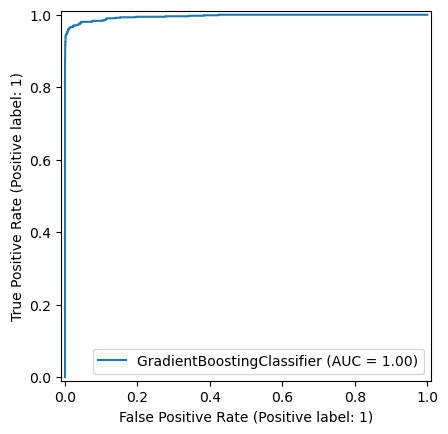



Confusion Matrix
[[2265   21]
 [  48  666]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.97      0.93      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000


 ROC AUC Score : 0.962



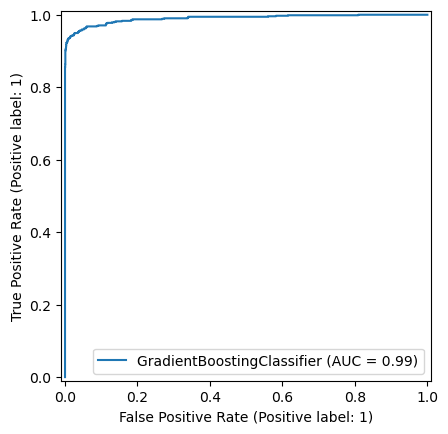



Confusion Matrix
[[2253   33]
 [  40  674]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2286
           1       0.95      0.94      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000


 ROC AUC Score : 0.965



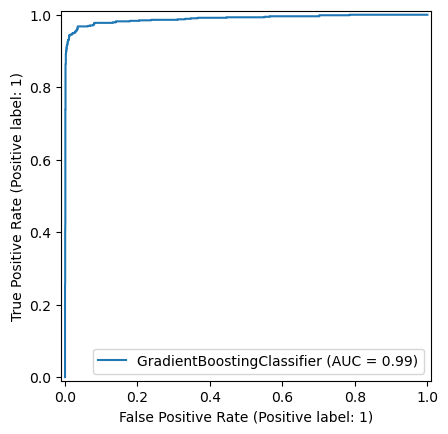



Confusion Matrix
[[2265   21]
 [  46  668]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2286
           1       0.97      0.94      0.95       714

    accuracy                           0.98      3000
   macro avg       0.97      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000


 ROC AUC Score : 0.963



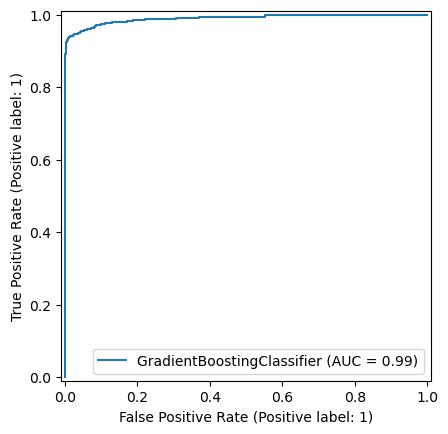



Confusion Matrix
[[2260   25]
 [  39  675]]

Classification Report
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      2285
           1       0.96      0.95      0.95       714

    accuracy                           0.98      2999
   macro avg       0.97      0.97      0.97      2999
weighted avg       0.98      0.98      0.98      2999


 ROC AUC Score : 0.967



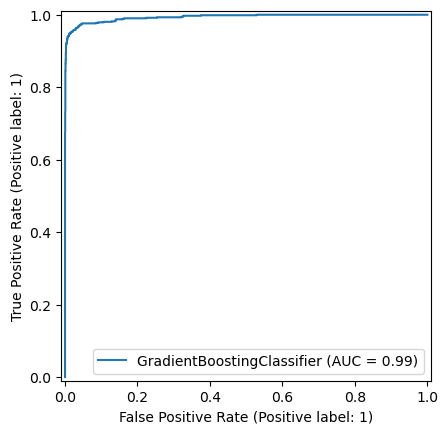

In [61]:
for train_data, test_data in validator.split(x, y):
    # Dividing the data into the different categories
    x_train = x.loc[train_data]
    y_train = y.loc[train_data]
    x_test = x.loc[test_data]
    y_test = y.loc[test_data]

    # Scaling the data
    x_train_sc = scaler.fit_transform(x_train)
    x_test_sc = scaler.transform(x_test)
    
    # Apply oversampling to the data.
    x_train_smote, y_train_smote = smote.fit_resample(x_train_sc, y_train)
    
    # Using the data to fit the Learning Model 
    gbc.fit(x_train_smote, y_train_smote)
    pred = gbc.predict(x_test_sc)

    print("Confusion Matrix")
    print(confusion_matrix(y_test, pred))
    print("\nClassification Report")
    print(classification_report(y_test, pred))
    print("\n ROC AUC Score :", roc_auc_score(y_test, pred).round(3))
    print("")

    log_disp = RocCurveDisplay.from_estimator(gbc, x_test_sc, y_test)
    plt.show()

    print("\n")

#### Based on the scores, the best model seems to be the Random Forest Classifier.

## Predicting probabilities using Random Forest Classifier

In [62]:
x.sample(5, random_state=123)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
6958,0.54,0.67,3,154,2,0,0,3,False,False,False,False,False,False,True,False,False
7534,0.72,0.52,3,143,4,1,0,1,False,False,False,False,False,False,False,True,False
2975,0.95,0.61,3,267,2,0,0,1,True,False,False,False,False,False,False,False,False
3903,0.78,0.79,3,203,2,0,0,1,False,False,False,False,False,False,True,False,False
8437,0.60,0.40,3,146,4,1,0,1,False,False,False,False,False,False,False,False,True


In [63]:
y.sample(5, random_state=123)

6958    0
7534    0
2975    0
3903    0
8437    0
Name: left, dtype: int64

In [64]:
# Creating and verifying Train and Test Data.
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state=123)

In [65]:
x_train.sample(5, random_state=123)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
1686,0.22,0.86,4,293,3,0,0,1,False,False,False,False,True,False,False,False,False
11300,0.77,0.76,6,263,6,0,0,1,False,False,False,False,False,False,True,False,False
6066,0.85,0.88,5,236,4,0,0,2,False,False,False,False,False,False,False,False,True
5007,0.84,0.94,4,246,2,1,0,2,False,False,False,False,False,False,False,True,False
4083,0.96,0.83,4,132,6,0,0,3,False,False,False,False,False,False,False,False,True


In [66]:
y_train.sample(5, random_state=123)

1686     1
11300    0
6066     0
5007     0
4083     0
Name: left, dtype: int64

In [67]:
x_test.sample(5, random_state=123)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,work_accident,promotion_last_5years,salary,dept_RandD,dept_accounting,dept_hr,dept_management,dept_marketing,dept_product_mng,dept_sales,dept_support,dept_technical
10582,0.62,0.50,4,156,2,0,0,2,False,False,False,False,False,False,False,True,False
2241,0.96,1.00,5,162,3,0,0,1,False,True,False,False,False,False,False,False,False
8788,0.67,0.83,3,220,3,0,0,1,False,False,False,False,False,False,True,False,False
4599,0.49,0.56,4,260,6,0,0,1,False,False,False,False,False,False,True,False,False
6636,0.65,0.60,3,218,4,0,0,2,True,False,False,False,False,False,False,False,False


In [68]:
y_test.sample(5, random_state=123)

10582    0
2241     0
8788     0
4599     0
6636     0
Name: left, dtype: int64

In [69]:
y_train.value_counts()

left
0    9142
1    2857
Name: count, dtype: int64

In [70]:
y_test.value_counts()

left
0    2286
1     714
Name: count, dtype: int64

In [71]:
# Defining Scaler
scaler2 = MinMaxScaler()

# Fitting and Transforming the X.
x_train_sc = scaler2.fit_transform(x_train)
x_test_sc = scaler2.transform(x_test)

In [72]:
x_train_sc.round(2)

array([[0.07, 0.05, 0.6 , ..., 1.  , 0.  , 0.  ],
       [0.  , 0.7 , 0.8 , ..., 0.  , 1.  , 0.  ],
       [0.53, 0.2 , 0.  , ..., 0.  , 1.  , 0.  ],
       ...,
       [0.3 , 0.23, 0.  , ..., 0.  , 1.  , 0.  ],
       [0.54, 0.67, 0.4 , ..., 0.  , 0.  , 0.  ],
       [0.84, 0.31, 0.2 , ..., 0.  , 0.  , 0.  ]])

In [73]:
x_test_sc.round(2)

array([[0.98, 0.64, 0.2 , ..., 1.  , 0.  , 0.  ],
       [0.74, 0.89, 0.2 , ..., 0.  , 0.  , 0.  ],
       [0.67, 0.89, 0.2 , ..., 0.  , 0.  , 0.  ],
       ...,
       [0.85, 0.98, 0.2 , ..., 0.  , 1.  , 0.  ],
       [0.6 , 0.11, 0.6 , ..., 1.  , 0.  , 0.  ],
       [0.77, 0.91, 0.4 , ..., 0.  , 0.  , 1.  ]])

In [74]:
# Apply SMOTE
smote2 = SMOTE(random_state = 123)
x_train_smote, y_train_smote = smote2.fit_resample(x_train_sc, y_train)

In [75]:
y_train_smote.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

In [76]:
# Defining the Learning Model
rfc2 = RandomForestClassifier(n_estimators=100, n_jobs = -1)

In [77]:
rfc2.fit(x_train_smote, y_train_smote)

RandomForestClassifier(n_jobs=-1)

In [78]:
pred = rfc2.predict(x_test_sc)

In [79]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      2286
           1       0.99      0.98      0.99       714

    accuracy                           0.99      3000
   macro avg       0.99      0.99      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [80]:
pred_proba = rfc2.predict_proba(x_test_sc)

In [81]:
pred

array([0, 0, 0, ..., 0, 0, 1], dtype=int64)

In [82]:
pred_proba[:, 1]

array([0.  , 0.34, 0.03, ..., 0.  , 0.02, 0.99])

In [83]:
x_scaled = scaler2.transform(x)
len(x_scaled)

14999

In [84]:
x_proba = rfc2.predict_proba(x_scaled)
x_proba[:, 1]

array([1., 1., 1., ..., 1., 1., 1.])

In [85]:
proba_df = pd.DataFrame(x_proba[:, 1], columns=["probability"])
proba_df

,probability
0,1.00
1,1.00
2,1.00
3,0.96
4,1.00
...,...
14994,1.00
14995,1.00
14996,1.00
14997,1.00


### Preparing a graph using the probablity Data

In [86]:
def categorize(x: float):
    if x < 0.2:
        return "Safe"
    elif x <= 0.6:
        return "Low"
    elif x <= 0.9:
        return "Medium"
    else:
        return "High"

categorize(0.77)

'Medium'

In [87]:
proba_df["zone"] = proba_df["probability"].apply(categorize)
proba_df.head()

,probability,zone
0,1.00,High
1,1.00,High
2,1.00,High
3,0.96,High
4,1.00,High


In [88]:
zone_df = proba_df["zone"].value_counts()
zone_df

zone
Safe      11333
High       3388
Medium      163
Low         115
Name: count, dtype: int64

In [89]:
def get_values(val):
    a  = np.round(val/100.*zone_df.sum(), 0)
    return int(a)

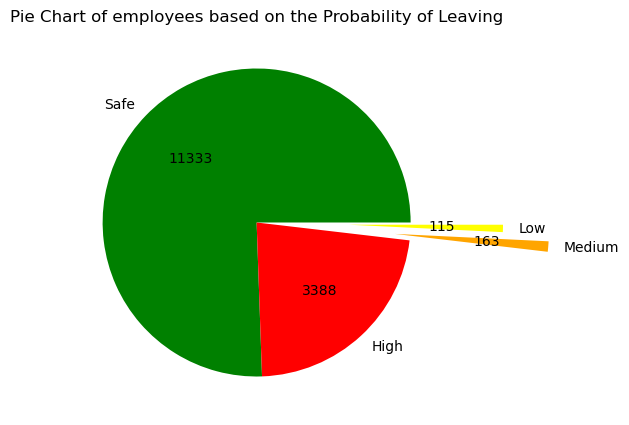

In [91]:
exp = [0, 0, 0.9, 0.6]
plt.subplots(figsize = (13, 5))
plt.title("Pie Chart of employees based on the Probability of Leaving")
plt.pie(zone_df, labels = zone_df.index, explode=exp, autopct=get_values, colors = ["green", "red", "orange", "yellow"])
plt.show()